# Rearrangement Testing

In [2]:
import os
# Change 'v13.x' to match the exact folder name on your computer!
os.environ['CUDA_PATH'] = r'C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v13.2'

import numpy as np
import cupy as cp
import math
import matplotlib.pyplot as plt
import time
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import lap

def get_jv_pairing_lap(init, final):
        """
        Solves using the 'lap' library (C++ Jonker-Volgenant implementation).
        Computes the cost matrix and padding efficiently on the GPU via CuPy.
        """
        N = len(init)
        M = len(final)
        
        # 1. Calculate Cost Matrix directly on GPU using CuPy broadcasting
        # init shape: (N, 2), final shape: (M, 2) -> cost_matrix shape: (N, M)
        cost_matrix = cp.sum((init[:, None, :] - final[None, :, :])**2, axis=-1)
        
        # 2. Handle Rectangularity (N != M) via padding
        if N != M:
            dim = max(N, M)
            # Create a large square matrix on the GPU filled with a high cost
            large_cost = float(cost_matrix.max() * 1000.0) if cost_matrix.size > 0 else 1.0
            padded_cost = cp.full((dim, dim), large_cost, dtype=cp.float32)
            
            # Fill in the real data
            padded_cost[:N, :M] = cost_matrix
            
            # TRANSFER TO CPU FOR C++ LAPJV (lap strictly requires numpy)
            padded_cost_cpu = padded_cost.get()
            opt_cost, x, y = lap.lapjv(padded_cost_cpu, extend_cost=True)
            
            # 3. Extract valid indices and map back to CuPy
            if N < M:
                init_idx = cp.arange(N)
                final_idx = cp.asarray(x[:N])
                
                valid_mask = final_idx < M
                init_idx = init_idx[valid_mask]
                final_idx = final_idx[valid_mask]
            else:
                final_idx = cp.arange(M)
                init_idx = cp.asarray(y[:M])
                
                valid_mask = init_idx < N
                final_idx = final_idx[valid_mask]
                init_idx = init_idx[valid_mask]
                
        else:
            # Square case is simple
            cost_matrix_cpu = cost_matrix.get()
            opt_cost, x, y = lap.lapjv(cost_matrix_cpu, extend_cost=True)
            init_idx = cp.arange(N)
            final_idx = cp.asarray(x)
            
        return init_idx, final_idx

def get_zernike_polynomial(noll_index, rho, theta, mask):
    """
    Returns the Zernike polynomial evaluated on the rho, theta grid 
    for a given Noll index.
    
    Includes the standard normalization constants so that the RMS 
    value of each polynomial over the unit disk is 1.
    """
    if noll_index == 1:
        # Piston
        Z = np.ones_like(rho)
    elif noll_index == 2:
        # Tip (X Tilt)
        Z = 2 * rho * np.cos(theta)
    elif noll_index == 3:
        # Tilt (Y Tilt)
        Z = 2 * rho * np.sin(theta)
    elif noll_index == 4:
        # Defocus
        Z = np.sqrt(3) * (2 * rho**2 - 1)
    elif noll_index == 5:
        # Oblique Astigmatism
        Z = np.sqrt(6) * rho**2 * np.sin(2 * theta)
    elif noll_index == 6:
        # Vertical Astigmatism
        Z = np.sqrt(6) * rho**2 * np.cos(2 * theta)
    elif noll_index == 7:
        # Vertical Coma
        Z = np.sqrt(8) * (3 * rho**3 - 2 * rho) * np.sin(theta)
    elif noll_index == 8:
        # Horizontal Coma
        Z = np.sqrt(8) * (3 * rho**3 - 2 * rho) * np.cos(theta)
    elif noll_index == 9:
        # Vertical Trefoil
        Z = np.sqrt(8) * rho**3 * np.sin(3 * theta)
    elif noll_index == 10:
        # Oblique Trefoil
        Z = np.sqrt(8) * rho**3 * np.cos(3 * theta)
    elif noll_index == 11:
        # Primary Spherical Aberration
        Z = np.sqrt(5) * (6 * rho**4 - 6 * rho**2 + 1)
    elif noll_index == 12:
        # Secondary Vertical Astigmatism
        Z = np.sqrt(10) * (4 * rho**4 - 3 * rho**2) * np.cos(2 * theta)
    elif noll_index == 13:
        # Secondary Oblique Astigmatism
        Z = np.sqrt(10) * (4 * rho**4 - 3 * rho**2) * np.sin(2 * theta)
    else:
        raise ValueError(f"Noll index {noll_index} is not implemented in this basic dictionary.")
        
    return Z * mask

class OptimisationBasedPhasemaskGeneratorGPU:
    def __init__(self,
                 wavelength_um=0.852,
                 focal_length_mm=10.0,
                 slm_pitch_um=8,
                 slm_res=(1200,1920),
                 input_beam_waist_mm=9.6,
                 fresnel_f_mm=600.0,
                 blaze_dx_dy_um=(63.0,7.0),
                 zernike_coeff_dict={5:-0.858, 6:0.282, 7:-1.725, 8:-0.434, 9:1.033, 10:-0.123, 11:1.048}):
        
        self.lam = wavelength_um
        self.f_mm = focal_length_mm
        self.f_um = focal_length_mm * 1000
        self.dx_slm = slm_pitch_um
        self.Ny, self.Nx = slm_res
        self.w0_mm = input_beam_waist_mm
        self.w0_um = input_beam_waist_mm * 1000
        self.Lx_slm = self.Nx * self.dx_slm # In units of um
        self.Ly_slm = self.Ny * self.dx_slm # In units of um
        self.dx_f = (self.lam * self.f_um) / self.Lx_slm # In units of um
        self.dy_f = (self.lam * self.f_um) / self.Ly_slm # In units of um
        self.Lx_foc = self.Nx * self.dx_f
        self.Ly_foc = self.Ny * self.dy_f
        self.x_slm = cp.linspace(-self.Lx_slm/2, self.Lx_slm/2, self.Nx, dtype=cp.float32)
        self.y_slm = cp.linspace(-self.Ly_slm/2, self.Ly_slm/2, self.Ny, dtype=cp.float32)

        # Precalculations
        self.k = np.float32(2 * np.pi / (self.lam * self.f_um))
        self.j_k = cp.complex64(1j) * self.k
        self.uint8_scale = cp.float32(255.0) / (2 * cp.pi)

        # Additional phasemasks - phase wrapped and in radians
        self.fresnel = self.generate_fresnel_lens_phasemask(focal_length_mm=fresnel_f_mm)
        self.blaze = self.generate_blazed_grating_phasemask(dx_um=blaze_dx_dy_um[0], dy_um=blaze_dx_dy_um[1])
        self.zernike = self.generate_zernike_phasemask(zernike_coeff_dict, wrap=True)
        
        print(f"--- System Configuration ---")
        print(f"SLM Plane Width: {self.Lx_slm/1000:.2f} mm")
        print(f"SLM Plane Height: {self.Ly_slm/1000:.2f} mm")
        print(f"Focal Plane Resolution x (pixel size): {self.dx_f:.4f} um")
        print(f"Focal Plane Resolution y (pixel size): {self.dy_f:.4f} um")
        print(f"Focal Plane Width: {self.Lx_foc:.2f} um")
        print(f"Focal Plane Height: {self.Ly_foc:.2f} um")
        print(f"Fresnel Lens Focal Length: {fresnel_f_mm:.2f} mm")
        print(f"Blazed Grating Displacement (dx, dy): {blaze_dx_dy_um} um")

    def generate_source_amplitude(self):
        """Generates Gaussian input beam amplitude."""
        X, Y = cp.meshgrid(self.x_slm, self.y_slm)
        R2 = X**2 + Y**2
        return cp.exp(- R2 / (2*(self.w0_um/2.355)**2))
    
    def generate_weighted_array(self, weights, spacing, init_phase_randomness=1.0):
        """
        Generates a weighted mask indicating where the tweezers should be and
        how strong they should be.
        Returns both the full 2D array and a list of the specific (y, x) indices.
        """
        dim = weights.shape
        xspan = (dim[1] - 1) * spacing
        yspan = (dim[0] - 1) * spacing
        xpos = np.linspace(-(xspan)/2, (xspan)/2, dim[1])
        ypos = np.linspace(-(yspan)/2, (yspan)/2, dim[0])
        Xpos, Ypos = np.meshgrid(xpos, ypos)
        Xn, Yn = Xpos.flatten(), Ypos.flatten()
        Wn = weights.flatten()
        Thetan = np.random.rand(len(Wn)) * init_phase_randomness * 2 * np.pi

        print(f"--- Target Generation ---")
        print(f"Grid: {dim[0]}x{dim[1]}")
        print(f"Spacing: {spacing} um")
                    
        return [Wn, Thetan, Xn, Yn, dim]
    
    def generate_zernike_phasemask(self, zernike_coeffs, wrap=False):
        """
        Generates a 2D Zernike correction phasemask defined on the SLM plane.
        
        Parameters:
        -----------
        settings : dict
            Must contain 'slm_shape' (Ny, Nx) and 'pixel_pitch' (p).
        zernike_coeffs : dict
            A dictionary mapping the Noll Index (int) to its coefficient (float).
            Example: {4: 1.5, 8: -0.5} applies 1.5 rads of Defocus and -0.5 rads of Horizontal Coma.
            
        Returns:
        --------
        total_phase : np.ndarray
            The 2D phase mask in radians to be applied to the SLM.
        """

        # 1. Setup SLM Coordinates (Centered at 0)
        X_slm, Y_slm = cp.meshgrid(self.x_slm, self.y_slm)
        R_max = cp.sqrt(self.Lx_slm**2 + self.Ly_slm**2) / 2.0
        rho = cp.sqrt(X_slm**2 + Y_slm**2) / R_max
        theta = cp.arctan2(Y_slm, X_slm)
        
        # 3. Define the unit circle mask
        mask = (rho <= 1.0).astype(float)
        
        # Initialize an empty phase array
        total_phase = cp.zeros((self.Ny, self.Nx))
        
        # 4. Superpose the requested Zernike modes
        for noll_index, coeff in zernike_coeffs.items():
            if coeff != 0.0:
                Z_mode = get_zernike_polynomial(noll_index, rho, theta, mask)
                total_phase += coeff * Z_mode

        return total_phase % (2 * cp.pi) - cp.pi

    def generate_fresnel_lens_phasemask(self, focal_length_mm):
        """
        Generates a Fresnel lens phase mask to focus the beam at a specific focal length.
        This is useful for correcting defocus or creating a virtual focus plane.
        """
        # 1. Setup SLM Coordinates (Centered at 0)
        X_slm, Y_slm = cp.meshgrid(self.x_slm, self.y_slm)
        
        # 2. Calculate the Fresnel lens phase profile
        f_um = focal_length_mm * 1000
        k = 2 * cp.pi / self.lam
        R_squared = X_slm**2 + Y_slm**2
        fresnel_phase = (k / (2 * f_um)) * R_squared
        
        return fresnel_phase % (2*cp.pi) - cp.pi
    
    def generate_blazed_grating_phasemask(self, dx_um, dy_um):
        """
        Generates a blazed grating phase mask to steer the beam by (dx_um, dy_um) in the focal plane.
        The steering angles are calculated based on the desired displacement and the system's focal length.
        """
        # 1. Setup SLM Coordinates (Centered at 0)
        X_slm, Y_slm = cp.meshgrid(self.x_slm, self.y_slm)
        
        # 2. Calculate steering angles
        theta_x = cp.arctan(dx_um / self.f_um)  # Steering angle in radians for x
        theta_y = cp.arctan(dy_um / self.f_um)  # Steering angle in radians for y
        
        # 3. Calculate the blazed grating phase profile
        k = 2 * cp.pi / self.lam
        blazed_phase = k * (X_slm * cp.sin(theta_x) + Y_slm * cp.sin(theta_y))
        return blazed_phase % (2*cp.pi) - cp.pi
    
    def superposition_optimization(self, target, max_iter=30, damping=0.4, verbose=True):
        """
        Optimizes a phasemask for a discrete array of optical tweezers using 
        the weighted superposition method, accelerated by the GPU using CuPy.
        """
            
        print("--- Starting GPU Superposition Phase Retrieval ---")
        start_time = time.time()

        # 3. Setup Illumination Beam (Gaussian)
        am_slm = cp.asarray(self.generate_source_amplitude())

        # 4. Define Target Trap Coordinates
        w_n, theta_n, x_n, y_n, array_shape = target
        
        # Move variables to GPU
        w_n_cp = cp.asarray(w_n)
        theta_n_cp = cp.asarray(theta_n)
        x_n_cp = cp.asarray(x_n)
        y_n_cp = cp.asarray(y_n)
        target_0_cp = cp.asarray(target[0])

        X_phase = cp.exp(self.j_k * x_n_cp[:, None] * self.x_slm[None, :]) # Shape: (N_traps, Nx)
        Y_phase = cp.exp(self.j_k * y_n_cp[:, None] * self.y_slm[None, :]) # Shape: (N_traps, Ny)
        X_phase_conj = cp.conj(X_phase)
        Y_phase_conj = cp.conj(Y_phase)

        uniformity_history = cp.zeros(max_iter)
        minmax_history = cp.zeros(max_iter)
        mse_history = cp.zeros(max_iter)
        
        mask_cp = target_0_cp > 0
        target_norm = target_0_cp / target_0_cp.sum()
        
        for iteration in range(max_iter):
            
            # Step A: Generate the Superposition Complex Field (Vectorized)
            C_n = w_n_cp * cp.exp(1j * theta_n_cp)
            Y_term = Y_phase * C_n[:, None]   # Shape: (N_traps, Ny)
            U_tot = Y_term.T @ X_phase      # Shape: (Ny, N_traps) @ (N_traps, Nx) -> (Ny, Nx)
            pm_slm = cp.angle(U_tot)
            
            # Step B: Evaluate Exact Intensity at Target Sites (Vectorized)
            U_slm = am_slm * cp.exp(1j * pm_slm)
            U_foc_n = U_slm @ X_phase_conj.T # Shape: (Ny, Nx) @ (Nx, N_traps) -> (Ny, N_traps)
            U_foc = cp.sum(Y_phase_conj * U_foc_n.T, axis=1) # Shape: (N_traps,)
            I_foc = cp.abs(U_foc)**2
                
            # Step C: Calculate Metrics
            I_foc_masked = I_foc[mask_cp]
            uniformity = 1.0 - (I_foc_masked.std() / I_foc_masked.mean()) # 1.0 is perfect uniformity
            uniformity_history[iteration] = uniformity
            
            I_foc_sum = I_foc.sum()
            I_foc_norm = I_foc / I_foc_sum
            mse = cp.mean((I_foc_norm - target_norm)**2)
            mse_history[iteration] = mse
            
            minmax_ratio = I_foc_masked.min() / I_foc_masked.max()
            minmax_history[iteration] = minmax_ratio
            
            # Step D: Update Weights
            update_ratio = (target_norm / I_foc_norm)**damping
            w_n_cp = w_n_cp * update_ratio
            
            # Update the target phases to match the simulated arriving field
            theta_n_cp = cp.angle(U_foc)
            
            if verbose:
                if iteration % 10 == 0:
                    print(f"Iteration {iteration:03d} | Mean-Squared Error: {float(mse):.2e} | Uniformity: {float(uniformity)*100:.2f}% | Min/Max ratio: {float(minmax_ratio):.3f}")

        trap_weights = I_foc.reshape(array_shape)
        print(f"Iteration {iteration:03d} | Mean-Squared Error: {float(mse):.2e} | Uniformity: {float(uniformity)*100:.2f}% | Min/Max ratio: {float(minmax_ratio):.3f}")
        print(f"Optimization finished in {time.time() - start_time:.2f} seconds.")
        
        return pm_slm, [w_n_cp, theta_n_cp, x_n_cp, y_n_cp, array_shape], [cp.asnumpy(uniformity_history), cp.asnumpy(minmax_history), cp.asnumpy(mse_history), cp.asnumpy(trap_weights)]

    def generate_phasemask(self, trap_terms):
        """
        Generates the phase mask using pure CuPy high-speed matrix multiplication.
        """
        # Unpack once
        w_n, theta_n, x_n, y_n, _ = trap_terms
        
        # 3. TRANSFER AND CAST TO 32-BIT
        # If your arrays are already on the GPU, cp.asarray does nothing (zero overhead)
        # Force float32 for maximum cuBLAS tensor core acceleration
        w_n_cp = cp.asarray(w_n, dtype=cp.float32)
        theta_n_cp = cp.asarray(theta_n, dtype=cp.float32)
        x_n_cp = cp.asarray(x_n, dtype=cp.float32)
        y_n_cp = cp.asarray(y_n, dtype=cp.float32)
        
        # 4. BUILD STEERING MATRICES (Using complex64 arithmetic)
        # Broadcasting: (N_traps, 1) * (1, Nx) -> (N_traps, Nx)
        X_phase = cp.exp(self.j_k * x_n_cp[:, None] * self.x_slm[None, :]) 
        Y_phase = cp.exp(self.j_k * y_n_cp[:, None] * self.y_slm[None, :]) 

        # 5. SUPERPOSITION COMPLEX FIELD
        # Combine weights and relative phases
        C_n = w_n_cp * cp.exp(cp.complex64(1j) * theta_n_cp)
        
        # Multiply weights into the Y_phase to create the Y_term: (N_traps, Ny)
        Y_term = Y_phase * C_n[:, None]   
        
        # The ultimate speedup: Matrix Multiplication (Ny, N_traps) @ (N_traps, Nx) -> (Ny, Nx)
        # This leverages NVIDIA's highly optimized cuBLAS backend instantly
        U_tot = Y_term.T @ X_phase      
        
        return cp.angle(U_tot)

    def simulate_focal_plane(self, pm_slm, Nx_pad=2048, Ny_pad=2048, show=False, zoom_pixels=100, cmap='viridis'):
        am_slm = cp.asarray(self.generate_source_amplitude())
        field_slm = am_slm * cp.exp(1j * cp.asarray(pm_slm))
        field_slm_pad = cp.zeros((Ny_pad, Nx_pad), dtype=cp.complex128)
        field_slm_pad[(Ny_pad - self.Ny)//2:(Ny_pad + self.Ny)//2, (Nx_pad - self.Nx)//2:(Nx_pad + self.Nx)//2] = field_slm
        field_foc_pad = cp.asnumpy(cp.fft.fftshift(cp.fft.fft2(cp.fft.fftshift(field_slm_pad))))

        if show:
            fig, ax = plt.subplots(1, 1, figsize=(6, 6))
            I_foc = np.abs(field_foc_pad)**2
            norm_intensity = I_foc / I_foc.max()
            x_focal_um = np.linspace(-self.Nx*self.dx_f/2, self.Nx*self.dx_f/2, Nx_pad)
            y_focal_um = np.linspace(-self.Ny*self.dy_f/2, self.Ny*self.dy_f/2, Ny_pad)
            im1 = ax.imshow(norm_intensity, 
                                extent=[x_focal_um[0], x_focal_um[-1], y_focal_um[0], y_focal_um[-1]],
                                cmap=cmap)

            zoom_range_um = zoom_pixels * self.dx_f
            ax.set_xlim(-zoom_range_um, zoom_range_um)
            ax.set_ylim(-zoom_range_um, zoom_range_um)
            ax.grid(False)
            ax.set_title(f"Simulated Intensity (Focal Plane)\nZoomed Central Region")
            ax.set_xlabel("x [um]")
            ax.set_ylabel("y [um]")
            cbar1 = plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
            cbar1.set_label("Normalized Intensity")

        return field_foc_pad
    
    def visualise_algorithm_performance(self, pm_slm, metrics, zoom_pixels, pad=1):
        U_foc = self.simulate_focal_plane(pm_slm, Nx_pad=self.Nx*pad, Ny_pad=self.Ny*pad, show=False)
        I_foc = np.abs(U_foc)**2

        fig, ax = plt.subplots(1, 3, figsize=(21, 6))
        uniformity_history, minmax_history, mse_history, trap_weights = metrics

        ax[0].plot(uniformity_history, 'b-o', label="Uniformity")
        ax[0].plot(minmax_history, 'r-s', label="Min/Max Ratio")
        ax0_secondary = ax[0].twinx()
        ax0_secondary.plot(mse_history, 'g-o', label="MSE")
        ax0_secondary.set_ylabel("MSE Value")
        ax0_secondary.tick_params(axis='y')
        ax0_secondary.legend(loc='lower right')
        ax[0].set_xlabel("Iteration")
        ax[0].set_ylabel("Metric Value")
        ax[0].legend(loc='upper right')
        ax[0].grid(True)
        
        ax[0].set_title("Optimization Convergence Metrics")

        norm_intensity = I_foc / I_foc.max()
        x_focal_um = np.linspace(-self.Nx*self.dx_f/2, self.Nx*self.dx_f/2, self.Nx*pad)
        y_focal_um = np.linspace(-self.Ny*self.dy_f/2, self.Ny*self.dy_f/2, self.Ny*pad)
        im1 = ax[1].imshow(norm_intensity, 
                            extent=[x_focal_um[0], x_focal_um[-1], y_focal_um[0], y_focal_um[-1]],
                            cmap='viridis')

        zoom_range_um = zoom_pixels * self.dx_f
        ax[1].set_xlim(-zoom_range_um, zoom_range_um)
        ax[1].set_ylim(-zoom_range_um, zoom_range_um)
        ax[1].grid(False)
        ax[1].set_title(f"Simulated Intensity (Focal Plane)\nZoomed Central Region")
        ax[1].set_xlabel("x [um]")
        ax[1].set_ylabel("y [um]")
        cbar1 = plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
        cbar1.set_label("Normalized Intensity")

        # Plot a heatmap of the trap weights with ax[2]
        im2 = ax[2].imshow(trap_weights/trap_weights.max(), cmap='viridis')
        ax[2].grid(False)
        ax[2].set_title("Simulated Trap Weights")
        ax[2].set_xlabel("Trap X Index")
        ax[2].set_ylabel("Trap Y Index")
        cbar2 = plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)
        cbar2.set_label("Normalized Trap Weight")

        plt.tight_layout()
        plt.show()

    def save_phasemask(self, phasemask):
        phasemask_bmp = Image.fromarray(phasemask)
        phasemask_bmp.save('C:\\Users\\CaFMOT\\OneDrive - Imperial College London\\caftweezers\\MeadowController\\phasemasks\\phasemask.bmp')
        print('Phasemask generated and saved as an 8bit.bmp')

    def superimpose(self, phasemasks):
        return cp.mod(sum(phasemasks), 2*cp.pi)
    
    def transform_phase_8bit(self, phasemask):
        return ((phasemask + cp.pi) * self.uint8_scale).astype(cp.uint8)
    
    def generate_rearrangement_sequence(self, terms1, terms2, occ_mask, w0=0.5):
        """
        Calculates the optimal Hungarian rearrangement path and generates 
        the full sequence of interpolated phasemasks efficiently on the GPU.
        """
        start = time.time()
    
        w1, phi1, x1, y1, _ = terms1
        w2, phi2, x2, y2, _ = terms2
        occ_mask = cp.asarray(occ_mask)
        
        pos1 = cp.stack((x1, y1), axis=-1)
        pos2 = cp.stack((x2, y2), axis=-1)

        # Jonker-Volgenant rearrangement algorithm implementation
        occ_indices = cp.where(occ_mask)[0]
        init = pos1[occ_indices]
        final = pos2
        
        init_idx, final_idx = get_jv_pairing_lap(init, final)
        
        # Map the Hungarian output back to the original array indices
        moving_idx = occ_indices[init_idx]
        
        # Compute mask for traps to be switched off
        off_mask = cp.ones(len(pos1), dtype=bool)
        off_mask[moving_idx] = False
        
        # 2. CALCULATE INTERPOLATION STEPS
        pos_init = pos1[moving_idx]
        pos_final = pos2[final_idx]
        vec = pos_final - pos_init
        
        max_dist = cp.sqrt((vec**2).sum(axis=1)).max()
        n_steps = int(max_dist // w0)
            
        # 3. INITIALIZE VRAM STATE MACHINE
        curr_w = cp.asarray(w1, dtype=cp.float32)
        curr_phi = cp.asarray(phi1, dtype=cp.float32)
        curr_x = cp.asarray(x1, dtype=cp.float32)
        curr_y = cp.asarray(y1, dtype=cp.float32)
        
        # Initialize step vectors with zeros
        dw = cp.zeros_like(curr_w)
        dphi = cp.zeros_like(curr_phi)
        dx = cp.zeros_like(curr_x)
        dy = cp.zeros_like(curr_y)
        
        # Load steps for MOVING traps
        dw[moving_idx] = cp.asarray((w2[final_idx] - w1[moving_idx]) / n_steps)
        dx[moving_idx] = cp.asarray(vec[:, 0] / n_steps)
        dy[moving_idx] = cp.asarray(vec[:, 1] / n_steps)
        
        # Ensure Phase Interpolation takes the shortest angular path to prevent 2*pi wrapping tears
        phase_diff = (phi2[final_idx] - phi1[moving_idx] + np.pi) % (2 * np.pi) - np.pi
        dphi[moving_idx] = cp.asarray(phase_diff / n_steps)
        
        # Load steps for OFF traps (Ramp down weights to 0)
        dw[off_mask] = cp.asarray(-w1[off_mask] / n_steps)
        
        phasemasks_sequence = np.empty((n_steps, self.Ny, self.Nx), dtype=np.uint8)
        gpu_sequence = cp.empty((n_steps, self.Ny, self.Nx), dtype=cp.uint8)
        
        
        # 4. THE ULTRA-FAST GPU LOOP
        for n in range(n_steps):
            # Advance state seamlessly in VRAM
            curr_w += dw
            curr_phi += dphi
            curr_x += dx
            curr_y += dy
            
            # Repack the terms and call the generator.
            terms_gpu = (curr_w, curr_phi, curr_x, curr_y, 0)
            pm_slm = self.generate_phasemask(terms_gpu)
            composite_pm = self.superimpose([pm_slm, self.fresnel, self.blaze, self.zernike])
            composite_pm_uint8 = self.transform_phase_8bit(composite_pm)
            
            # Pull the calculated 2D mask back to host memory (CPU)
            gpu_sequence[n] = composite_pm_uint8

        gpu_sequence.get(out=phasemasks_sequence)
            
        print(f"Time Taken for {n_steps} frames: {(time.time() - start)*1000:.4f} ms")
        return phasemasks_sequence

In [3]:
PM = OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=10.0,
                 slm_pitch_um=8,
                 slm_res=(1200,1920),
                 input_beam_waist_mm=9.6)

--- System Configuration ---
SLM Plane Width: 15.36 mm
SLM Plane Height: 9.60 mm
Focal Plane Resolution x (pixel size): 0.5547 um
Focal Plane Resolution y (pixel size): 0.8875 um
Focal Plane Width: 1065.00 um
Focal Plane Height: 1065.00 um
Fresnel Lens Focal Length: 600.00 mm
Blazed Grating Displacement (dx, dy): (63.0, 7.0) um


In [4]:
W = np.ones((15, 15))
spacing_um = 4

target1 = PM.generate_weighted_array(W, spacing_um, init_phase_randomness=1.0)
pm_slm1, terms1, _ = PM.superposition_optimization(target1, max_iter=500, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 15x15
Spacing: 4 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 3.17e-06 | Uniformity: 59.93% | Min/Max ratio: 0.090
Iteration 010 | Mean-Squared Error: 5.06e-08 | Uniformity: 94.94% | Min/Max ratio: 0.708
Iteration 020 | Mean-Squared Error: 5.62e-09 | Uniformity: 98.31% | Min/Max ratio: 0.912
Iteration 030 | Mean-Squared Error: 2.87e-09 | Uniformity: 98.79% | Min/Max ratio: 0.939
Iteration 040 | Mean-Squared Error: 9.72e-10 | Uniformity: 99.30% | Min/Max ratio: 0.962
Iteration 050 | Mean-Squared Error: 9.06e-10 | Uniformity: 99.32% | Min/Max ratio: 0.967
Iteration 060 | Mean-Squared Error: 9.87e-10 | Uniformity: 99.29% | Min/Max ratio: 0.963
Iteration 070 | Mean-Squared Error: 6.14e-10 | Uniformity: 99.44% | Min/Max ratio: 0.968
Iteration 080 | Mean-Squared Error: 9.47e-10 | Uniformity: 99.31% | Min/Max ratio: 0.966
Iteration 090 | Mean-Squared Error: 4.48e-10 | Uniformity: 99.52% | Min/Max ratio: 0.974
Iterati

In [5]:
W = np.ones((10, 10))
spacing_um = 4

target2 = PM.generate_weighted_array(W, spacing_um, init_phase_randomness=1.0)
pm_slm2, terms2, _ = PM.superposition_optimization(target2, max_iter=500, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 10x10
Spacing: 4 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.57e-05 | Uniformity: 60.43% | Min/Max ratio: 0.147
Iteration 010 | Mean-Squared Error: 2.46e-07 | Uniformity: 95.04% | Min/Max ratio: 0.744
Iteration 020 | Mean-Squared Error: 2.84e-08 | Uniformity: 98.32% | Min/Max ratio: 0.905
Iteration 030 | Mean-Squared Error: 7.80e-09 | Uniformity: 99.12% | Min/Max ratio: 0.953
Iteration 040 | Mean-Squared Error: 2.08e-09 | Uniformity: 99.54% | Min/Max ratio: 0.977
Iteration 050 | Mean-Squared Error: 7.06e-09 | Uniformity: 99.16% | Min/Max ratio: 0.966
Iteration 060 | Mean-Squared Error: 4.09e-09 | Uniformity: 99.36% | Min/Max ratio: 0.969
Iteration 070 | Mean-Squared Error: 1.73e-09 | Uniformity: 99.58% | Min/Max ratio: 0.976
Iteration 080 | Mean-Squared Error: 1.11e-09 | Uniformity: 99.67% | Min/Max ratio: 0.983
Iteration 090 | Mean-Squared Error: 1.02e-09 | Uniformity: 99.68% | Min/Max ratio: 0.982
Iterati

---

In [6]:
occ_mask = np.random.choice([True, False], size=len(terms1[0]))
occ_mask[occ_mask].shape

(115,)

In [12]:
pm_slm_list = PM.generate_rearrangement_sequence(terms1, terms2, occ_mask, w0=0.5)

Time Taken for 23 frames: 16.0005 ms


---
# Verification

In [41]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# You can reduce these if rendering is too slow
Nx_pad = 2048 * 2
Ny_pad = 2048 * 2

fig, ax = plt.subplots(figsize=(6, 6))

# Initialize with first frame
pm0 = pm_slm_list[0] * (2 * np.pi / 255) - np.pi
field0 = PM.simulate_focal_plane(pm0, Nx_pad=Nx_pad, Ny_pad=Ny_pad, show=False)
I0 = np.abs(field0) ** 2
norm0 = I0 / I0.max()

im = ax.imshow(
    norm0,
    extent=[-PM.Nx * PM.dx_f, PM.Nx * PM.dx_f, -PM.Ny * PM.dy_f, PM.Ny * PM.dy_f],
    cmap="viridis",
    animated=True
)
ax.set_xlim(-80, 80)
ax.set_ylim(-80, 80)
title = ax.set_title("norm_intensity frame 0")

def update(i):
    pm = pm_slm_list[i] * (2 * np.pi / 255) - np.pi
    field_foc = PM.simulate_focal_plane(pm, Nx_pad=Nx_pad, Ny_pad=Ny_pad, show=False)
    I_foc = np.abs(field_foc) ** 2
    norm_intensity = I_foc / I_foc.max()

    im.set_data(norm_intensity)
    title.set_text(f"norm_intensity frame {i}")
    return im, title

anim = FuncAnimation(fig, update, frames=len(pm_slm_list), interval=200, blit=False)
plt.close(fig)

HTML(anim.to_jshtml())


---

In [13]:
from pytweezer import communication as comm
SLM = comm.SLMClient()

In [14]:
composite_pm = PM.superimpose([pm_slm1, PM.fresnel, PM.blaze, PM.zernike])
composite_pm_uint8 = PM.transform_phase_8bit(composite_pm).get()
SLM.update_mask(composite_pm_uint8)

{'status': 'success', 'msg': 'Mask updated successfully.'}

In [24]:
test_pm = np.random.uniform(low=0, high=255, size=(1920, 1200)).astype(np.uint8)
SLM.update_mask(test_pm)

{'status': 'success', 'msg': 'Mask updated successfully.'}

In [13]:
for pm in pm_slm_list:
    SLM.update_mask(pm)
    time.sleep(0.1)

In [28]:
for _ in range(10):
    SLM.run_sequence(pm_slm_list, fps=1000)
    time.sleep(4)

---

In [6]:
import zmq
import time
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup ZeroMQ Subscriber
context = zmq.Context()
socket = context.socket(zmq.SUB)
socket.connect("tcp://10.59.3.1:5556")

# Subscribe to all messages (empty string means no topic filtering)
socket.setsockopt_string(zmq.SUBSCRIBE, "") 

# 2. Setup the timer and storage
listen_duration = 20 # seconds
start_time = time.time()
image_list = []

print(f"Listening for camera images for {listen_duration} seconds...")

# 3. Listen loop
try:
    while time.time() - start_time < listen_duration:
        # Poll the socket for 100ms so we don't block the Jupyter cell forever
        # This allows the while loop to frequently check the 60-second timer
        if socket.poll(100):
            img_bytes = socket.recv()
            
            # Reconstruct the 200x200 uint16 image from the raw bytes
            # Note: If you changed the size in the server, update it here!
            img_array = np.frombuffer(img_bytes, dtype=np.uint16).reshape((200, 200))
            image_list.append(img_array)
            
            print(f"Received image {len(image_list)} at {time.strftime('%H:%M:%S')}")
            
except KeyboardInterrupt:
    print("Listening interrupted by user.")

finally:
    # Always clean up your sockets in Jupyter to prevent port-locking!
    socket.close()
    context.term()
    print(f"Finished. Collected {len(image_list)} images.")

Listening for camera images for 20 seconds...
Received image 1 at 14:58:41
Received image 2 at 14:58:41
Received image 3 at 14:58:42
Received image 4 at 14:58:42
Received image 5 at 14:58:43
Received image 6 at 14:58:43
Received image 7 at 14:58:44
Received image 8 at 14:58:45
Received image 9 at 14:58:45
Received image 10 at 14:58:46
Received image 11 at 14:58:46
Received image 12 at 14:58:47
Received image 13 at 14:58:47
Received image 14 at 14:58:48
Received image 15 at 14:58:49
Received image 16 at 14:58:49
Received image 17 at 14:58:50
Received image 18 at 14:58:50
Received image 19 at 14:58:51
Received image 20 at 14:58:51
Received image 21 at 14:58:52
Received image 22 at 14:58:53
Received image 23 at 14:58:53
Received image 24 at 14:58:54
Received image 25 at 14:58:54
Received image 26 at 14:58:55
Received image 27 at 14:58:55
Received image 28 at 14:58:56
Received image 29 at 14:58:56
Received image 30 at 14:58:57
Received image 31 at 14:58:58
Received image 32 at 14:58:58
Fin

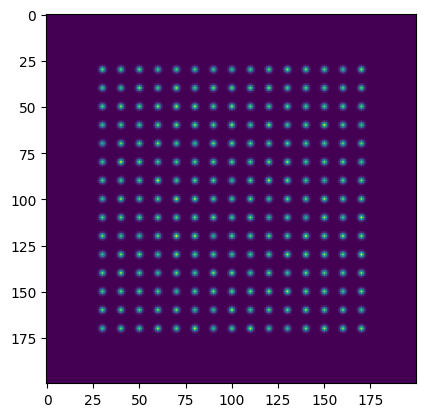

In [17]:
mean_img = np.array(image_list).mean(axis=0)
plt.imshow(mean_img)

Looking for trap sites...
15x15 array detected.


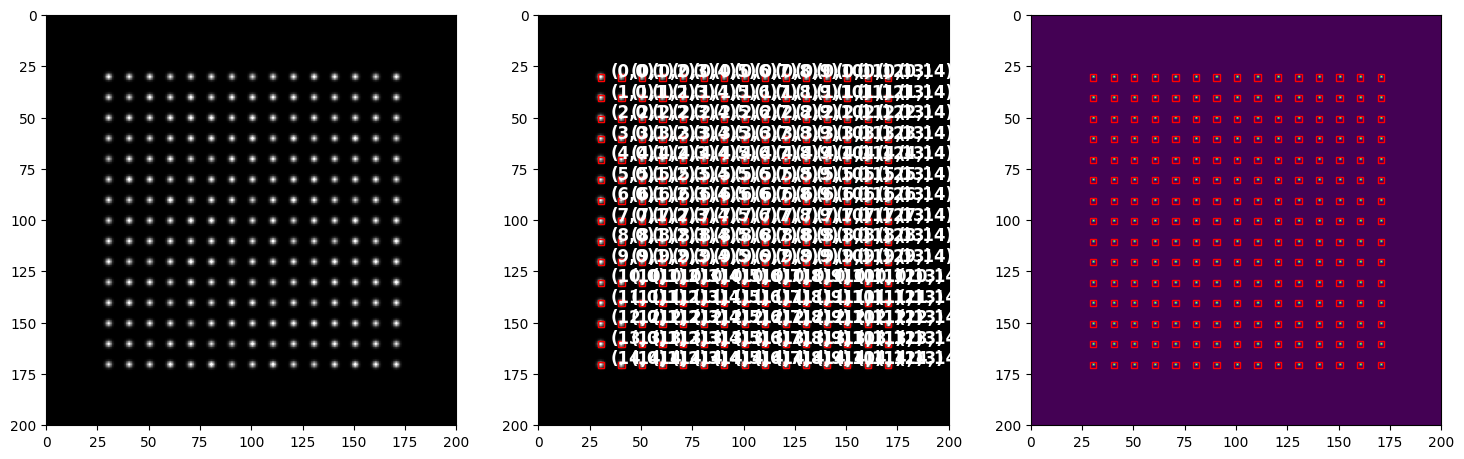

In [18]:
# extract trap positions
from pytweezer import analysis as an

grid_positions, detection_threshold = an.detect_trap_sites(mean_img, [15, 15], detection_step=100)
threshold = 100000
an.visualize_results(mean_img, grid_positions, margin=50, window_size=3, threshold=detection_threshold, vmaxfactor = 0.8)

In [56]:
image_array = np.array(image_list)[0]
pixel_sums = an.sum_pixel_values(image_array, grid_positions, [15, 15], window_size=5)
occ_mask = np.zeros(len(pixel_sums.flatten()), dtype=bool)
occ_mask[pixel_sums.flatten() > threshold] = True

In [1]:
pm_slm_list = PM.generate_rearrangement_sequence(terms1, terms2, occ_mask, w0=0.5)

NameError: name 'PM' is not defined

---

In [19]:


# 1. Setup ZeroMQ Subscriber
context = zmq.Context()
socket = context.socket(zmq.SUB)
socket.connect("tcp://10.59.3.1:5556")

# Subscribe to all messages (empty string means no topic filtering)
socket.setsockopt_string(zmq.SUBSCRIBE, "") 

# 2. Setup the timer and storage
listen_duration = 60 # seconds
start_time = time.time()

print(f"Listening for camera images for {listen_duration} seconds...")

# 3. Listen loop
state = 0
try:
    while time.time() - start_time < listen_duration:
        # Poll the socket for 100ms so we don't block the Jupyter cell forever
        # This allows the while loop to frequently check the 60-second timer
        if socket.poll(100):
            img_bytes = socket.recv()
            if state == 0:
                # Reconstruct the 200x200 uint16 image from the raw bytes
                # Note: If you changed the size in the server, update it here!
                img_array = np.frombuffer(img_bytes, dtype=np.uint16).reshape((200, 200))
                print(f"Received image at {time.strftime('%H:%M:%S')}")

                pixel_sums = an.sum_pixel_values(img_array, grid_positions, [15, 15], window_size=5)
                occ_mask = np.zeros(len(pixel_sums.flatten()), dtype=bool)
                occ_mask[pixel_sums.flatten() > threshold] = True

                pm_slm_list = PM.generate_rearrangement_sequence(terms1, terms2, occ_mask, w0=0.5)
                SLM.run_sequence(pm_slm_list, fps=10000)
                state = 1
            elif state == 1:
                SLM.update_mask(composite_pm_uint8)
                state = 0
        
except KeyboardInterrupt:
    print("Listening interrupted by user.")

finally:
    # Always clean up your sockets in Jupyter to prevent port-locking!
    socket.close()
    context.term()
    print(f"Finished.")

Listening for camera images for 60 seconds...
Received image at 14:09:15
Time Taken for 16 frames: 12.0003 ms
Received image at 14:09:21
Time Taken for 16 frames: 11.9998 ms
Received image at 14:09:27
Time Taken for 20 frames: 19.9997 ms
Received image at 14:09:34
Time Taken for 20 frames: 13.0002 ms
Received image at 14:09:40
Time Taken for 20 frames: 14.9992 ms
Received image at 14:09:46
Time Taken for 20 frames: 15.0003 ms
Received image at 14:09:52
Time Taken for 20 frames: 20.9992 ms
Received image at 14:09:58
Time Taken for 16 frames: 12.0001 ms
Received image at 14:10:04
Time Taken for 20 frames: 14.9996 ms
Received image at 14:10:10
Time Taken for 20 frames: 22.0001 ms
Finished.


---
---
# Array Rearrangement Guide

Initialise and start idle rearrangement process node.

In [1]:
import multiprocessing as mp
from pytweezer import analysis as an
from pytweezer import phasemask as pm
from pytweezer import communication as com
from pytweezer.rearrangement_node import RearrangementNode
import numpy as np
import time
import zmq

# Create BOTH queues
control_q = mp.Queue()
message_q = mp.Queue()

# Initialize and start (don't forget .start()!)
worker = RearrangementNode(control_q, message_q)
worker.start()

# To read the logs generated by the background process:
while not message_q.empty():
    print(message_q.get())

[Rearrangement Node] Initialised.


Create phasemask generator object

In [2]:
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=10.0,
                 slm_pitch_um=8,
                 slm_res=(1200,1920),
                 input_beam_waist_mm=9.6)

--- System Configuration ---
SLM Plane Width: 15.36 mm
SLM Plane Height: 9.60 mm
Focal Plane Resolution x (pixel size): 0.5547 um
Focal Plane Resolution y (pixel size): 0.8875 um
Focal Plane Width: 1065.00 um
Focal Plane Height: 1065.00 um
Fresnel Lens Focal Length: 600.00 mm
Blazed Grating Displacement (dx, dy): (63.0, 7.0) um


Create initial 15x15 array phasemask

In [3]:
W = np.ones((15, 15))
spacing_um = 4

target1 = PM.generate_weighted_array(W, spacing_um, init_phase_randomness=1.0)
pm_slm1, terms1, _ = PM.superposition_optimization(target1, max_iter=500, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 15x15
Spacing: 4 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 3.15e-06 | Uniformity: 60.07% | Min/Max ratio: 0.103
Iteration 010 | Mean-Squared Error: 2.32e-08 | Uniformity: 96.58% | Min/Max ratio: 0.794
Iteration 020 | Mean-Squared Error: 7.49e-09 | Uniformity: 98.05% | Min/Max ratio: 0.897
Iteration 030 | Mean-Squared Error: 4.88e-09 | Uniformity: 98.43% | Min/Max ratio: 0.913
Iteration 040 | Mean-Squared Error: 1.08e-09 | Uniformity: 99.26% | Min/Max ratio: 0.954
Iteration 050 | Mean-Squared Error: 2.18e-10 | Uniformity: 99.67% | Min/Max ratio: 0.979
Iteration 060 | Mean-Squared Error: 1.43e-10 | Uniformity: 99.73% | Min/Max ratio: 0.983
Iteration 070 | Mean-Squared Error: 9.64e-11 | Uniformity: 99.78% | Min/Max ratio: 0.985
Iteration 080 | Mean-Squared Error: 7.05e-11 | Uniformity: 99.81% | Min/Max ratio: 0.987
Iteration 090 | Mean-Squared Error: 8.98e-11 | Uniformity: 99.79% | Min/Max ratio: 0.987
Iterati

Create final 10x10 array phasemask

In [4]:
W = np.ones((10, 10))
spacing_um = 4

target2 = PM.generate_weighted_array(W, spacing_um, init_phase_randomness=1.0)
pm_slm2, terms2, _ = PM.superposition_optimization(target2, max_iter=500, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 10x10
Spacing: 4 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.37e-05 | Uniformity: 62.97% | Min/Max ratio: 0.138
Iteration 010 | Mean-Squared Error: 2.19e-07 | Uniformity: 95.31% | Min/Max ratio: 0.779
Iteration 020 | Mean-Squared Error: 3.11e-08 | Uniformity: 98.24% | Min/Max ratio: 0.925
Iteration 030 | Mean-Squared Error: 1.33e-08 | Uniformity: 98.85% | Min/Max ratio: 0.946
Iteration 040 | Mean-Squared Error: 6.64e-09 | Uniformity: 99.19% | Min/Max ratio: 0.964
Iteration 050 | Mean-Squared Error: 2.76e-09 | Uniformity: 99.47% | Min/Max ratio: 0.973
Iteration 060 | Mean-Squared Error: 3.62e-09 | Uniformity: 99.40% | Min/Max ratio: 0.972
Iteration 070 | Mean-Squared Error: 1.50e-09 | Uniformity: 99.61% | Min/Max ratio: 0.984
Iteration 080 | Mean-Squared Error: 5.20e-10 | Uniformity: 99.77% | Min/Max ratio: 0.990
Iteration 090 | Mean-Squared Error: 2.20e-10 | Uniformity: 99.85% | Min/Max ratio: 0.993
Iterati

Connect to SLM. Create initial composite phasemask and upload to SLM.

In [5]:
SLM = com.SLMClient()
pm_init = PM.superimpose([pm_slm1, PM.fresnel, PM.blaze, PM.zernike])
pm_init_uint8 = PM.transform_phase_8bit(pm_init).get()
SLM.update_mask(pm_init_uint8)

{'status': 'success', 'msg': 'Mask updated successfully.'}

Run baseline experiment to extract grid positions and detection threshold.

In [6]:
# 1. Setup ZeroMQ Subscriber
context = zmq.Context()
socket = context.socket(zmq.SUB)
socket.connect("tcp://10.59.3.1:5556")

# Subscribe to all messages (empty string means no topic filtering)
socket.setsockopt_string(zmq.SUBSCRIBE, "") 

# 2. Setup the timer and storage
listen_duration = 20 # seconds
start_time = time.time()
image_list = []

print(f"Listening for camera images for {listen_duration} seconds...")

# 3. Listen loop
try:
    while time.time() - start_time < listen_duration:
        # Poll the socket for 100ms so we don't block the Jupyter cell forever
        # This allows the while loop to frequently check the 60-second timer
        if socket.poll(100):
            img_bytes = socket.recv()
            
            # Reconstruct the 200x200 uint16 image from the raw bytes
            # Note: If you changed the size in the server, update it here!
            img_array = np.frombuffer(img_bytes, dtype=np.uint16).reshape((200, 200))
            image_list.append(img_array)
            
            print(f"Received image {len(image_list)} at {time.strftime('%H:%M:%S')}")
            
except KeyboardInterrupt:
    print("Listening interrupted by user.")

finally:
    # Always clean up your sockets in Jupyter to prevent port-locking!
    socket.close()
    context.term()
    print(f"Finished. Collected {len(image_list)} images.")

Listening for camera images for 20 seconds...
Received image 1 at 17:46:30
Received image 2 at 17:46:30
Received image 3 at 17:46:30
Received image 4 at 17:46:30
Received image 5 at 17:46:31
Received image 6 at 17:46:31
Received image 7 at 17:46:31
Received image 8 at 17:46:31
Received image 9 at 17:46:31
Received image 10 at 17:46:31
Received image 11 at 17:46:32
Received image 12 at 17:46:32
Received image 13 at 17:46:32
Received image 14 at 17:46:32
Received image 15 at 17:46:32
Received image 16 at 17:46:32
Received image 17 at 17:46:33
Received image 18 at 17:46:33
Received image 19 at 17:46:33
Received image 20 at 17:46:33
Received image 21 at 17:46:33
Received image 22 at 17:46:33
Received image 23 at 17:46:34
Received image 24 at 17:46:34
Received image 25 at 17:46:34
Received image 26 at 17:46:34
Received image 27 at 17:46:34
Received image 28 at 17:46:34
Received image 29 at 17:46:35
Received image 30 at 17:46:35
Received image 31 at 17:46:35
Received image 32 at 17:46:35
Rec

Looking for trap sites...
15x15 array detected.


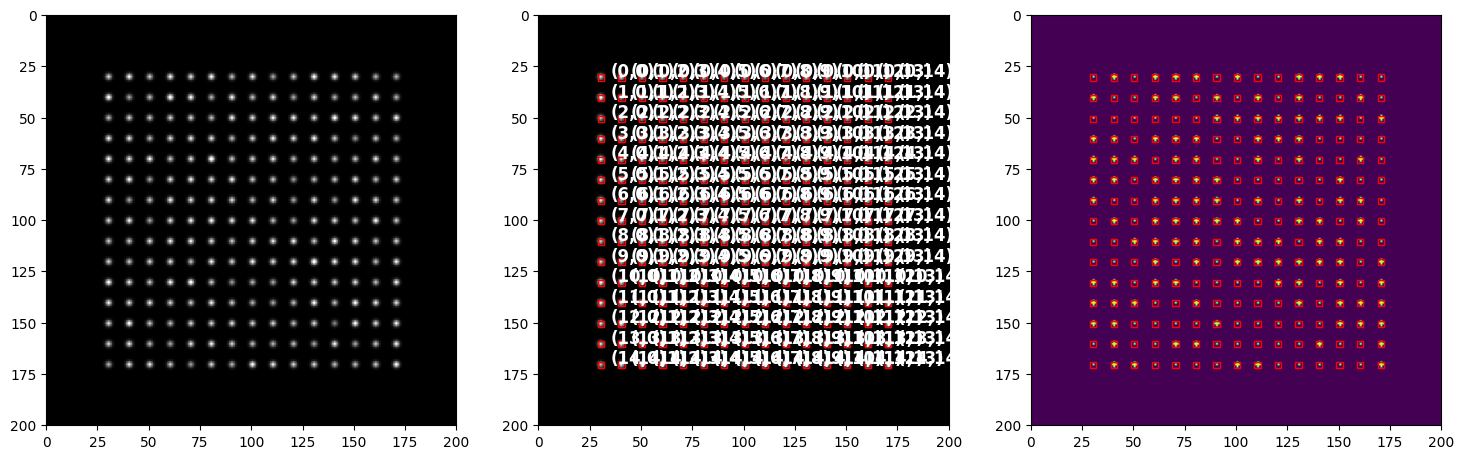

In [7]:
mean_img = np.array(image_list).mean(axis=0)
grid_positions, detection_threshold = an.detect_trap_sites(mean_img, [15, 15], detection_step=100)
an.visualize_results(mean_img, grid_positions, margin=50, window_size=3, threshold=detection_threshold, vmaxfactor = 0.8)

threshold = 100000

Arm the rearrangement node before running experiment.

In [8]:
print("Arming the rearrangement node...")
control_q.put({
    "type": "ARM",
    "pm_init": pm_init_uint8,
    "terms1": terms1,
    "terms2": terms2,
    "d0": 0.5,
    "threshold": threshold,
    "img_shape": (200,200),
    "grid_positions": grid_positions,
    "initial_array_shape":[15,15],
    "fps": 100000000
})

Arming the rearrangement node...


In [18]:
while not message_q.empty():
    print(message_q.get())

[Rearrangement Node] Image received! Executing pipeline...
[Rearrangement Node] Rearrangement sequence generated.
[Rearrangement Node] SLM upload duration: 0.325210 s
[Rearrangement Node] Total rearrangement duration: 0.393211 s
[Rearrangement Node] Rearragement complete. Disarming...
[Rearrangement Node] Image received! Executing pipeline...
[Rearrangement Node] Rearrangement sequence generated.
[Rearrangement Node] SLM upload duration: 0.636142 s
[Rearrangement Node] Total rearrangement duration: 0.671144 s
[Rearrangement Node] Rearragement complete. Disarming...
[Rearrangement Node] Image received! Executing pipeline...
[Rearrangement Node] Rearrangement sequence generated.
[Rearrangement Node] SLM upload duration: 0.314569 s
[Rearrangement Node] Total rearrangement duration: 0.338569 s
[Rearrangement Node] Rearragement complete. Disarming...
[Rearrangement Node] Image received! Executing pipeline...
[Rearrangement Node] Rearrangement sequence generated.
[Rearrangement Node] SLM upl